In [1]:
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

In [2]:
path = kagglehub.dataset_download("uciml/iris")

print(path)

Using Colab cache for faster access to the 'iris' dataset.
/kaggle/input/iris


In [3]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


In [4]:
df = pd.read_csv("/kaggle/input/iris/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [8]:
X = df.drop(
    ["Id", "Species"],
    axis=1
)

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# K-Means Clustering

In [9]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

clusters[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [10]:
df["Cluster"] = clusters

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1


# PCA Dimensionality Reduction

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(X_pca.shape)

(150, 2)


In [12]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-2.684207,0.326607,1
1,-2.715391,-0.169557,1
2,-2.889820,-0.137346,1
3,-2.746437,-0.311124,1
4,-2.728593,0.333925,1


# Visualize Clusters

In [13]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os

project_folder = "/content/drive/MyDrive/Week3_Iris_Clustering"

os.makedirs(
    project_folder,
    exist_ok=True
)

print("Folder ready")

Folder ready


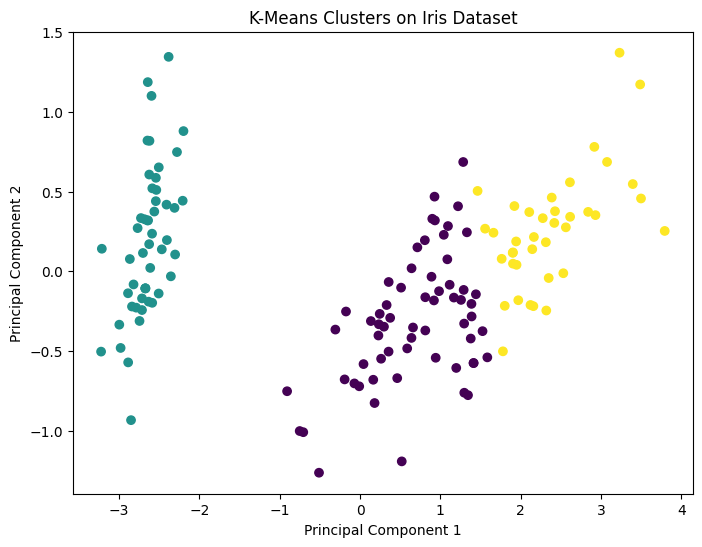

Cluster plot saved


In [15]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"]
)

plt.title("K-Means Clusters on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

cluster_plot = f"{project_folder}/kmeans_clusters.png"

plt.savefig(
    cluster_plot,
    bbox_inches="tight"
)

plt.show()

print("Cluster plot saved")

In [16]:
le = LabelEncoder()

true_labels = le.fit_transform(
    df["Species"]
)

true_labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [17]:
cm = confusion_matrix(
    true_labels,
    clusters
)

print(cm)

[[ 0 50  0]
 [48  0  2]
 [14  0 36]]


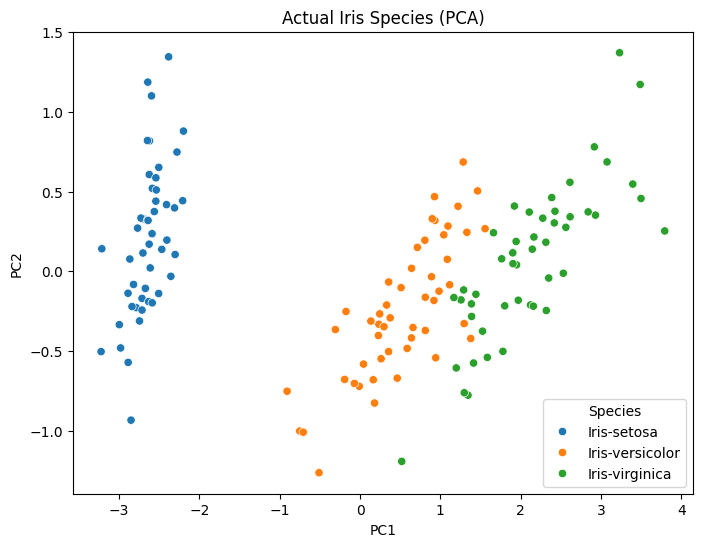

PCA plot saved


In [18]:
pca_df["Species"] = df["Species"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species"
)

plt.title("Actual Iris Species (PCA)")

pca_plot = f"{project_folder}/pca_visualization.png"

plt.savefig(
    pca_plot,
    bbox_inches="tight"
)

plt.show()

print("PCA plot saved")

In [19]:
with open(
    f"{project_folder}/results.txt",
    "w"
) as f:

    f.write("K-Means Clustering on Iris Dataset\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(cm))

print("Results saved")

Results saved
